# PCO213 — Otimização de ensembles por arranjo de misturas: estudo no Santander

**Aluno:** Caio Tertuliano Ribeiro — matrícula 2026102152

Este notebook cobre a **análise exploratória (EDA)**, documenta o **pré-processamento** e apresenta os **resultados** do estudo (lidos dos artefatos salvos em `experiments/pco213/santander/` pelo pipeline `scripts/pco213_run_santander_study.py`).

Reprodução completa (≈15–20 min no dataset cheio):
```
.venv-pco213/bin/python scripts/pco213_run_santander_study.py --mode full_optional
```
O notebook é reexecutável: as células de EDA releem o dado bruto e as de resultados releem os artefatos.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src' / 'mixens').exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'src'))
OUT = REPO / 'experiments' / 'pco213' / 'santander'
FIG = REPO / 'figures' / 'pco213'

from mixens import data as data_mod

pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

## 1. Dados e validação de invariantes

O `train.csv` oficial (200.000 linhas, 200 features numéricas anônimas `var_0..var_199`, alvo binário `target`) é adquirido pela cascata pré-registrada (Kaggle CLI → mirror público → instruções manuais) e validado contra os invariantes oficiais **antes de qualquer uso** (nº de linhas, nº de features, taxa de positivos, ausência de missing). O `test.csv` oficial não possui rótulos e é descartado — toda a avaliação supervisionada deriva do `train.csv`.

In [2]:
X, y, meta = data_mod.load_santander(REPO / 'data' / 'pco213' / 'raw' / 'santander',
                                     mode='full_optional', random_state=42)
print(json.dumps(data_mod.meta_dict(meta), indent=2))

{
  "source": "local",
  "sha256": "704545baab73fe42e2b3bcc7eb0aac3d2dfd3ce7f0c9ea65ec45d08ebce6596e",
  "n_rows_raw": 200000,
  "n_duplicates_dropped": 0,
  "n_rows": 200000,
  "n_features": 200,
  "pos_rate": 0.10049,
  "mode": "full_optional",
  "sample_size": null,
  "random_state": 42
}


## 2. Análise exploratória (EDA estrutural)

As features são **anonimizadas** — não há semântica de domínio a explorar. A EDA é, portanto, *estrutural*: balanceamento de classes, estatísticas resumidas, formas das distribuições por classe, **estrutura de correlação** (o achado notável deste dataset) e poder discriminativo individual das features.

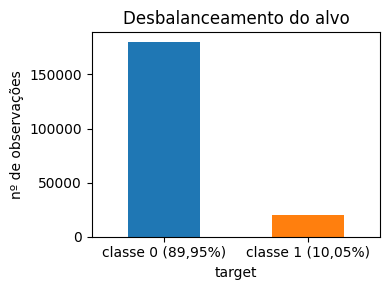

In [3]:
fig, ax = plt.subplots(figsize=(4, 3))
y.value_counts().plot.bar(ax=ax, color=['tab:blue', 'tab:orange'])
ax.set_xticklabels(['classe 0 (89,95%)', 'classe 1 (10,05%)'], rotation=0)
ax.set_ylabel('nº de observações')
ax.set_title('Desbalanceamento do alvo')
plt.tight_layout()
FIG.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG / 'fig1_eda_class_balance.png', dpi=200)
plt.show()

In [4]:
# Estatísticas resumidas (amostra de features)
X[[f'var_{i}' for i in [0, 1, 12, 81, 139, 199]]].describe().T

,count,mean,std,min,25%,50%,75%,max
var_0,"200,000.0000",10.6799,3.0401,0.4084,8.4538,10.5247,12.7582,20.3150
var_1,"200,000.0000",-1.6276,4.0500,-15.0434,-4.7400,-1.6081,1.3586,10.3768
var_12,"200,000.0000",14.0240,0.1901,13.4346,13.8940,14.0255,14.1642,14.6545
var_81,"200,000.0000",14.7190,2.2996,7.5865,13.2148,14.8445,16.3408,23.1324
var_139,"200,000.0000",7.7602,7.6864,-21.2743,2.3876,8.0662,13.2325,36.0971
var_199,"200,000.0000",-3.3265,10.4380,-38.8528,-11.2085,-2.8196,4.8368,28.5007


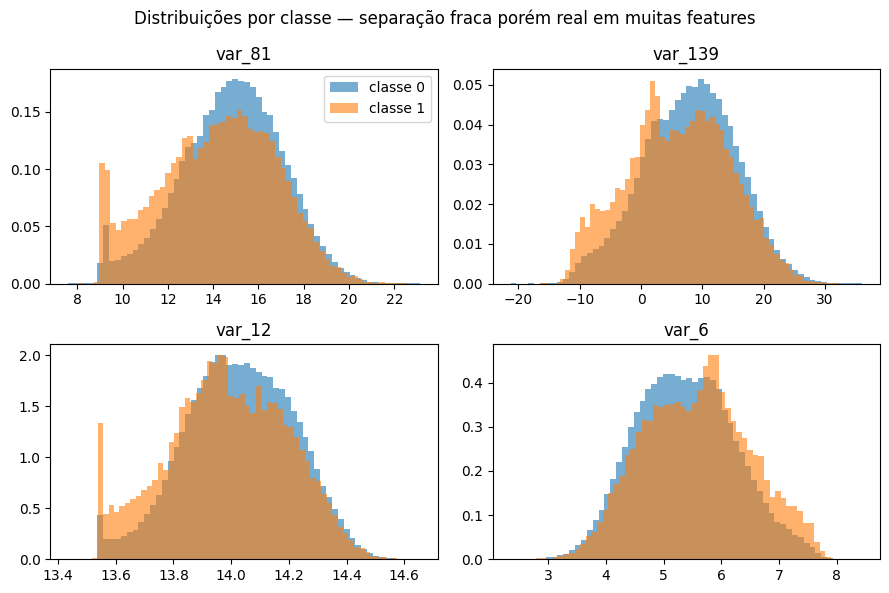

In [5]:
# Distribuições por classe (features de maior AUC individual — ver célula seguinte)
sel = ['var_81', 'var_139', 'var_12', 'var_6']
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
for axi, c in zip(axes.ravel(), sel):
    axi.hist(X.loc[y == 0, c], bins=60, alpha=0.6, density=True, label='classe 0')
    axi.hist(X.loc[y == 1, c], bins=60, alpha=0.6, density=True, label='classe 1')
    axi.set_title(c)
axes[0, 0].legend()
fig.suptitle('Distribuições por classe — separação fraca porém real em muitas features')
plt.tight_layout()
plt.show()

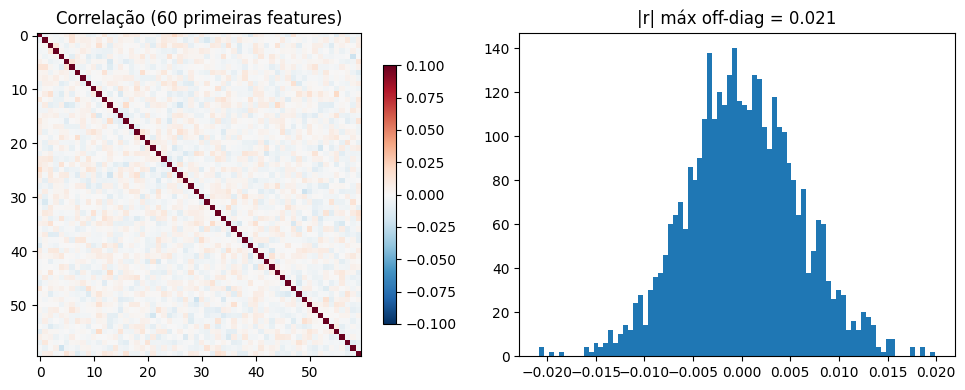

Features praticamente independentes → explica por que o GaussianNB (que assume independência) é competitivo neste problema.


In [6]:
# Estrutura de correlação: matriz ~identidade (achado central da EDA)
sub = X.sample(30_000, random_state=0)
corr = np.corrcoef(sub.iloc[:, :60].T.to_numpy())
off = corr[~np.eye(len(corr), dtype=bool)]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im = axes[0].imshow(corr, vmin=-0.1, vmax=0.1, cmap='RdBu_r')
axes[0].set_title('Correlação (60 primeiras features)')
fig.colorbar(im, ax=axes[0], shrink=0.8)
axes[1].hist(off, bins=80)
axes[1].set_title(f'|r| máx off-diag = {np.abs(off).max():.3f}')
plt.tight_layout()
plt.savefig(FIG / 'fig1b_eda_correlation.png', dpi=200)
plt.show()
print('Features praticamente independentes → explica por que o GaussianNB '
      '(que assume independência) é competitivo neste problema.')

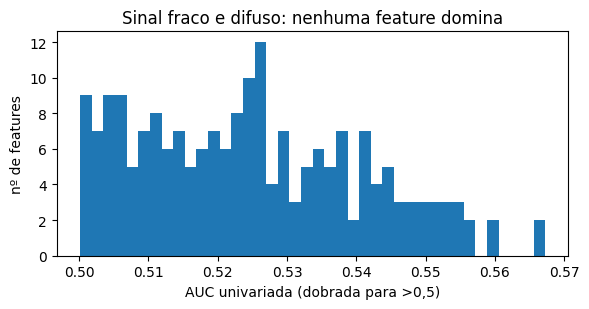

AUC univariada: mediana 0.524, máx 0.567 (var_81)


{'max_univariate_auc': 0.5672385728989441,
 'median_univariate_auc': 0.5240374649736186,
 'best_univariate_feature': 'var_81',
 'max_abs_offdiag_corr': 0.02082669163844681,
 'n_rows': 200000,
 'pos_rate': 0.10049}

In [7]:
# Poder discriminativo individual: AUC univariada por feature
from sklearn.metrics import roc_auc_score
aucs = np.array([max(a := roc_auc_score(y, X[c]), 1 - a) for c in X.columns])
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(aucs, bins=40)
ax.set_xlabel('AUC univariada (dobrada para >0,5)')
ax.set_ylabel('nº de features')
ax.set_title('Sinal fraco e difuso: nenhuma feature domina')
plt.tight_layout()
plt.show()
print(f'AUC univariada: mediana {np.median(aucs):.3f}, máx {aucs.max():.3f} '
      f'({X.columns[np.argmax(aucs)]})')
# Persiste o resumo estrutural da EDA para o gerador de macros do artigo
eda_summary = {
    'max_univariate_auc': float(aucs.max()),
    'median_univariate_auc': float(np.median(aucs)),
    'best_univariate_feature': str(X.columns[np.argmax(aucs)]),
    'max_abs_offdiag_corr': float(np.abs(off).max()),
    'n_rows': int(len(X)),
    'pos_rate': float(y.mean()),
}
OUT.mkdir(parents=True, exist_ok=True)
(OUT / 'eda_summary.json').write_text(json.dumps(eda_summary, indent=2))
eda_summary

## 3. Pré-processamento (decisões documentadas)

- **Sem valores ausentes e sem categóricas** (validado): não há imputação nem encoding;
- `ID_code` descartado; **deduplicação** verificada (0 duplicatas em features+alvo);
- **Escalonamento (StandardScaler) apenas dentro dos pipelines** de LR e kNN, ajustado fold a fold — evita vazamento; modelos de árvore não são escalonados;
- **Sem reamostragem (SMOTE/oversampling)**: o desbalanceamento (10%) é tratado pela estratificação da CV e pela escolha de métricas (ROC-AUC primária); reamostrar antes do split é o erro clássico deste dataset;
- **Probabilidades dos componentes clipadas** em [10⁻³, 1−10⁻³] antes do log-loss (kNN/GNB produzem 0/1 exatos) — o blend permanece linear nos pesos;
- Features de contagem/frequência (a “mágica” da competição) são **proibidas**: transdutivas (dependem do test set), vazariam no protocolo interno.

## 4. Protocolo experimental e decisão de runtime

Holdout externo 80/20 estratificado → `RepeatedStratifiedKFold(5×2)` no treino → matrizes OOF `P` (uma por repetição) → **21 pontos** do arranjo de misturas ({5,2} + centroide + 5 axiais) + **25 pontos Dirichlet** de validação avaliados sobre `P` → Scheffé quadrático → otimização (SLSQP direto vs. ótimo do metamodelo) → **confirmação única no holdout**. O microbenchmark abaixo justificou o modo `full_optional` (dataset completo).

In [8]:
display(pd.read_csv(OUT / 'microbenchmark.csv'))
print(json.dumps(json.loads((OUT / 'execution_decision.json').read_text()), indent=2))

,model,n_fit,n_predict,fit_seconds,predict_seconds
0,lr,16000,4000,0.0159,0.0013
1,gnb,16000,4000,0.0076,0.0010
2,knn,16000,4000,0.0122,0.1808
3,et,16000,4000,0.3151,0.0250
4,rf,16000,4000,3.2800,0.0318
5,xgb,16000,4000,1.8227,0.0024


{
  "mode": "full_optional",
  "third_slot": "knn",
  "n_rows": 200000,
  "estimated_minutes": 15.0,
  "max_runtime_minutes": 120.0,
  "downgraded": false,
  "attempts": [
    {
      "mode": "full_optional",
      "third_slot": "knn",
      "n_rows": 200000,
      "estimated_minutes": 15.0
    }
  ]
}


## 5. Modelos-base: desempenho OOF por fold (10 rodadas)

roc_auc        log_loss         brier       
         mean    std     mean    std   mean    std
model                                             
gnb    0.8879 0.0038   0.2108 0.0025 0.0604 0.0006
knn    0.7258 0.0045   0.3527 0.0012 0.0922 0.0001
lr     0.8592 0.0043   0.2321 0.0023 0.0665 0.0006
rf     0.8457 0.0040   0.2748 0.0006 0.0793 0.0001
xgb    0.8820 0.0044   0.2194 0.0027 0.0632 0.0007

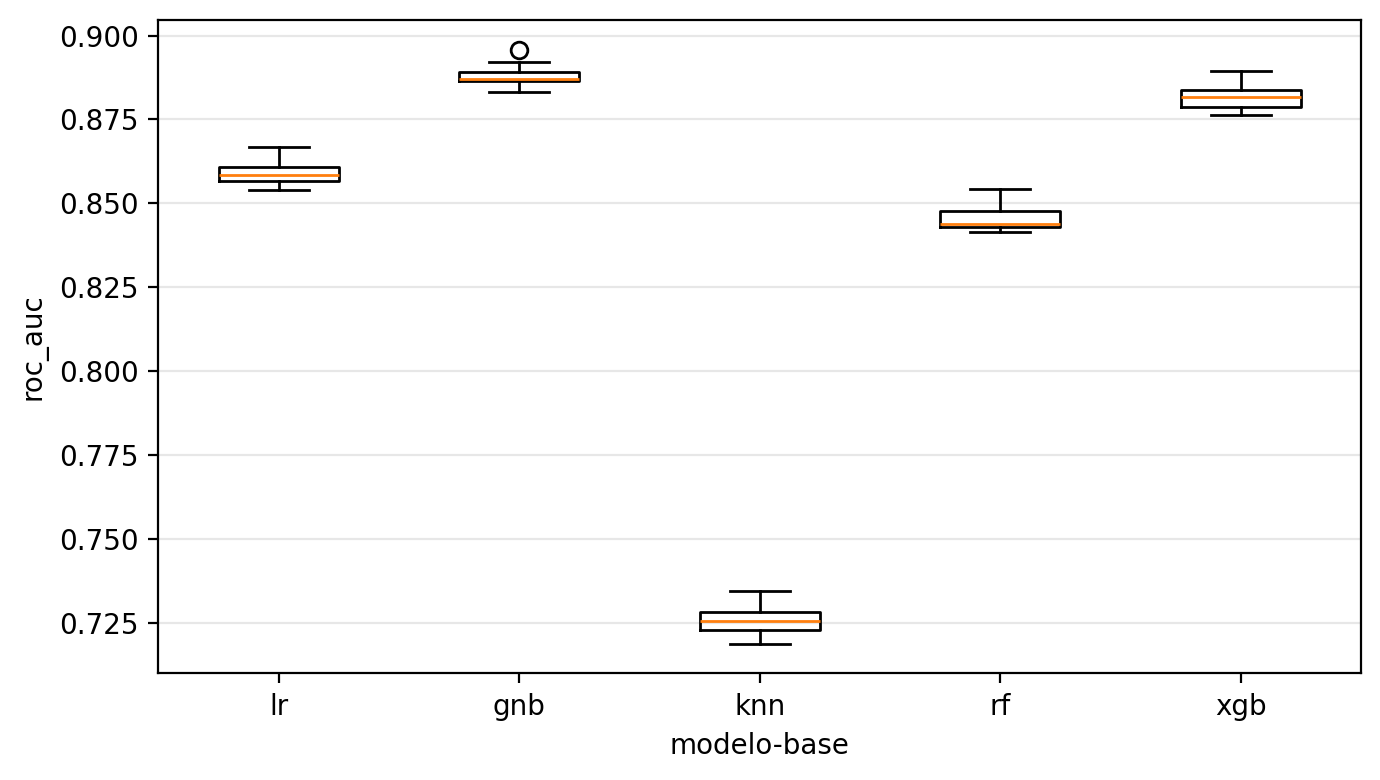

In [9]:
fm = pd.read_csv(OUT / 'fold_metrics_models.csv')
display(fm.groupby('model')[['roc_auc', 'log_loss', 'brier']].agg(['mean', 'std']).round(4))
from mixens.plots import fig_model_fold_boxplots
fig_model_fold_boxplots(fm, FIG / 'fig2_base_models_auc.png')
from IPython.display import Image
Image(FIG / 'fig2_base_models_auc.png', width=640)

## 6. Superfície de mistura: metamodelo de Scheffé

O polinômio quadrático de Scheffé é ajustado por repetição (faixas de estabilidade) e no design agrupado (42 observações = 21 pontos × 2 repetições). A validação externa usa os 25 pontos Dirichlet, **não usados no ajuste**.

In [10]:
rep = json.loads((OUT / 'scheffe_report.json').read_text())
for metric in ['roc_auc', 'log_loss', 'brier']:
    r = rep[metric]
    ev = r['external_validation']
    print(f"{metric:9s}  R²={r['pooled_r2']:.4f}  R²adj={r['pooled_r2_adj']:.4f}  "
          f"cond={r['condition_number']:.1f}  RMSE_ext={ev['rmse']:.5f} "
          f"({100*ev['rmse_relative_to_range']:.1f}% da amplitude)")
display(pd.read_csv(OUT / 'scheffe_coefficients_roc_auc.csv').round(4))

roc_auc    R²=0.9632  R²adj=0.9442  cond=11.8  RMSE_ext=0.00754 (46.1% da amplitude)
log_loss   R²=0.9948  R²adj=0.9921  cond=11.8  RMSE_ext=0.00251 (4.3% da amplitude)
brier      R²=1.0000  R²adj=1.0000  cond=11.8  RMSE_ext=0.00000 (0.0% da amplitude)


,term,mean,min,max
0,w_lr,0.8584,0.8584,0.8585
1,w_gnb,0.8868,0.8868,0.8869
2,w_knn,0.7312,0.7308,0.7316
3,w_rf,0.8467,0.8466,0.8469
4,w_xgb,0.8814,0.8813,0.8814
5,w_lr*w_gnb,0.0136,0.0136,0.0136
6,w_lr*w_knn,0.2587,0.2584,0.2591
7,w_lr*w_rf,0.0908,0.0904,0.0911
8,w_lr*w_xgb,0.0358,0.0354,0.0362
9,w_gnb*w_knn,0.3045,0.3044,0.3046


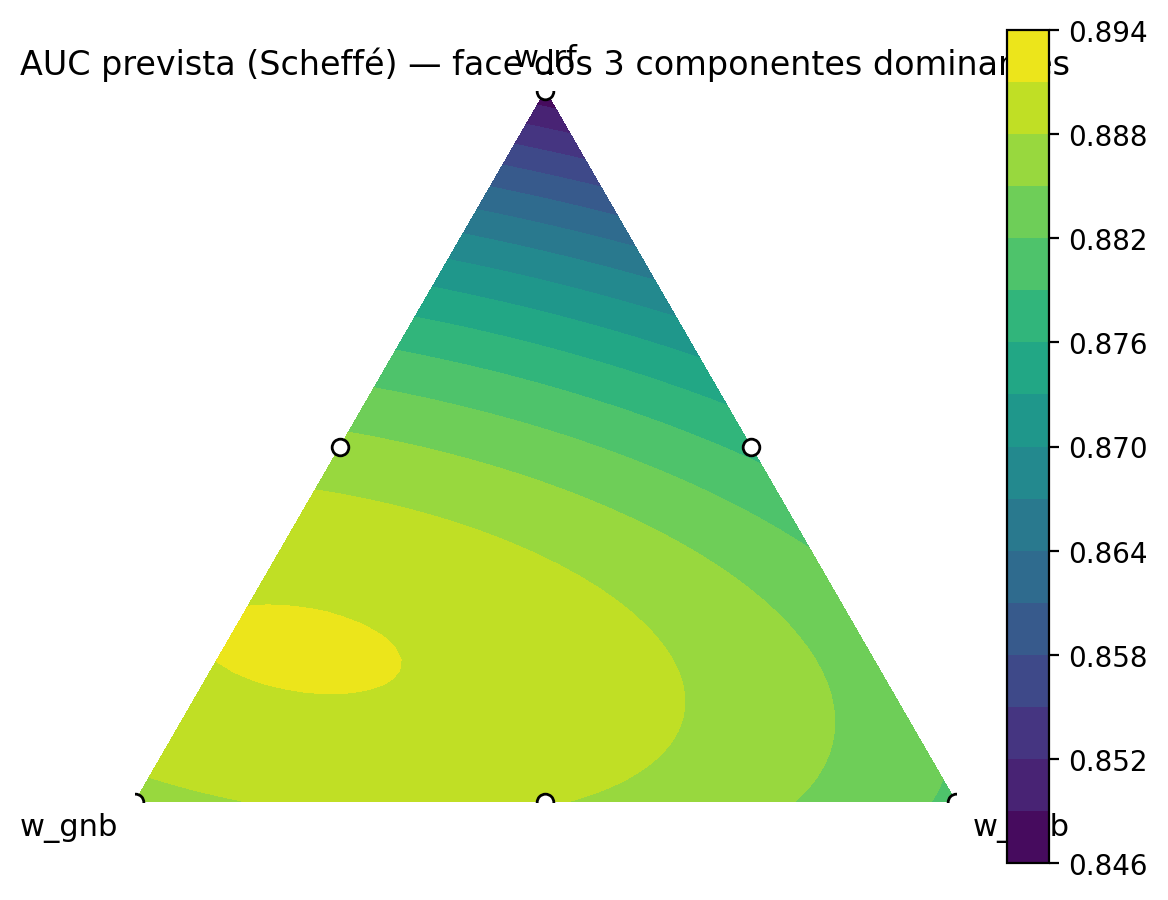

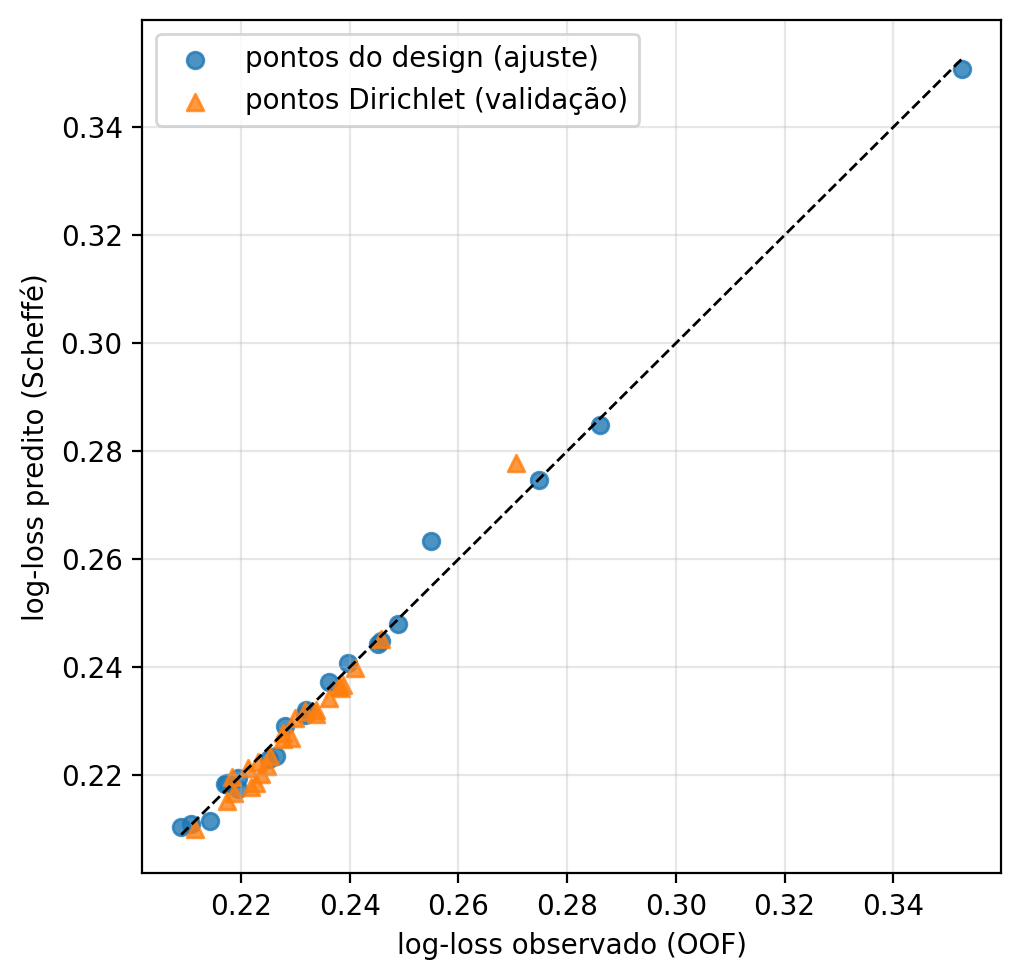

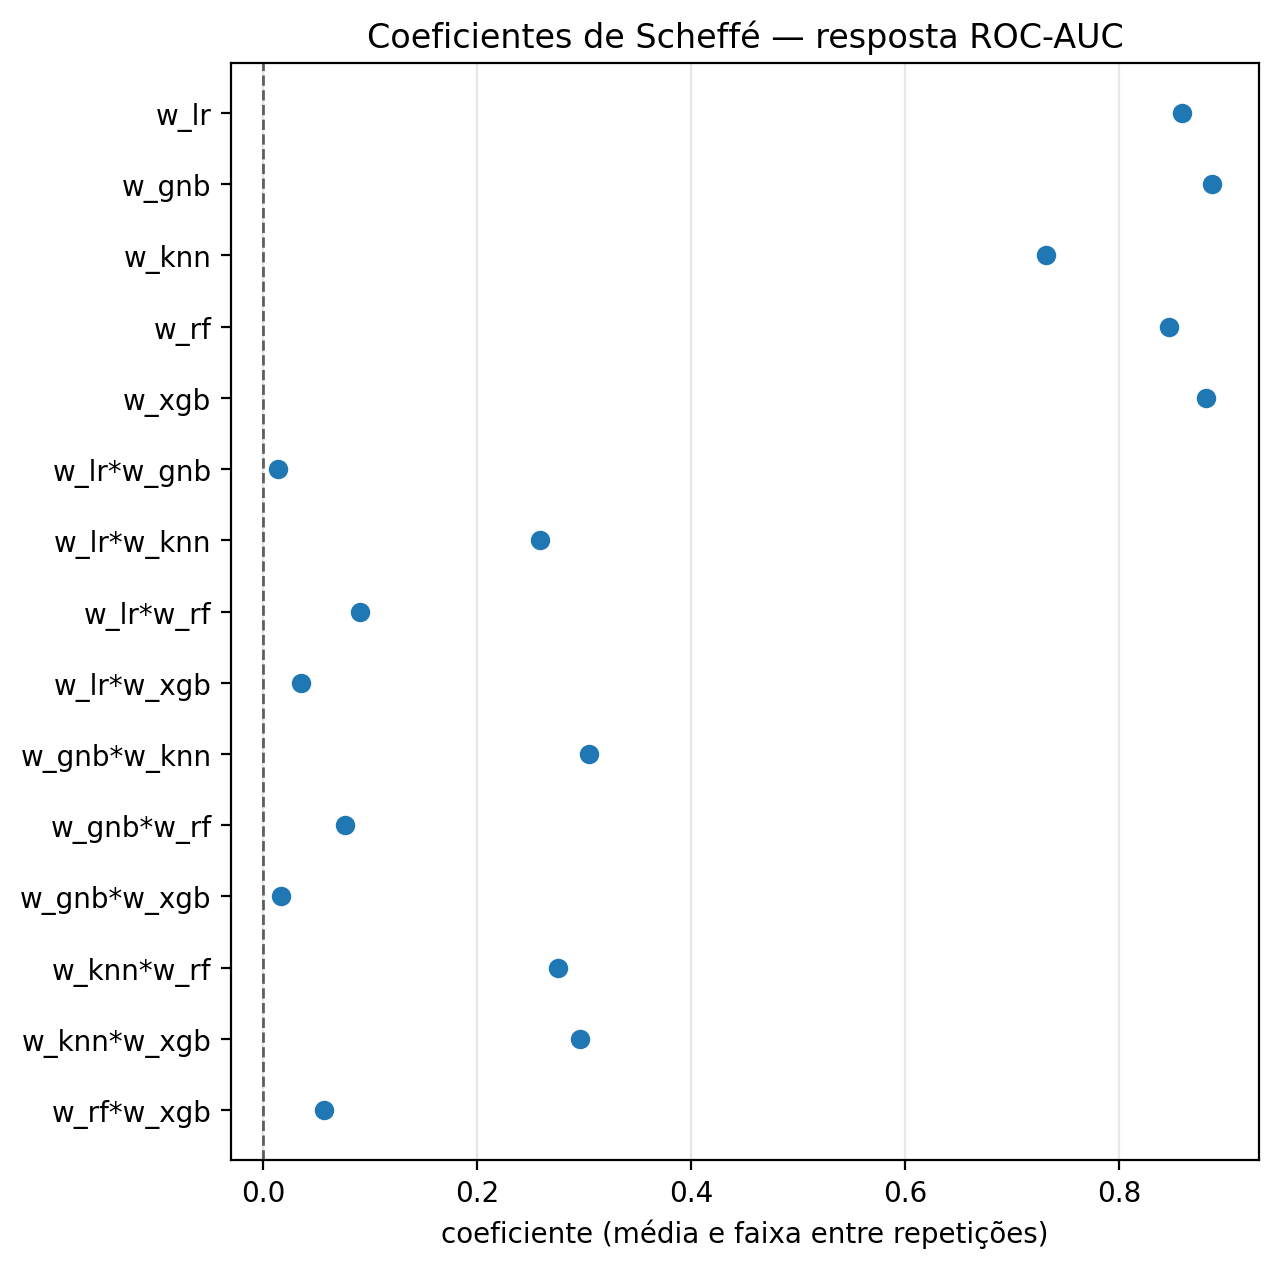

In [11]:
from IPython.display import Image
display(Image(FIG / 'fig3_ternary_auc.png', width=560))
display(Image(FIG / 'fig4_pred_vs_obs_logloss.png', width=520))
display(Image(FIG / 'fig5_scheffe_coefficients_auc.png', width=620))

## 7. Comparação final no holdout

Todos os métodos usam **as mesmas matrizes OOF** (seleção de pesos/limiar apenas na OOF) e são confirmados **uma única vez** no holdout de 20%.

,method,roc_auc,log_loss,brier,f1,balanced_accuracy,oof_roc_auc,oof_log_loss
0,best_single,0.8822,0.2170,0.0624,0.5361,0.7534,0.8879,0.2108
1,uniform_voting,0.8896,0.2271,0.0663,0.5467,0.7547,0.8895,0.2264
2,stacking_lr,0.8863,0.2171,0.0615,0.5490,0.7584,0.8869,0.2148
3,slsqp_direct_logloss,0.8890,0.2115,0.0608,0.5489,0.7632,0.8919,0.2084
4,scheffe_optimum_logloss,0.8849,0.2154,0.0620,0.5412,0.7553,0.8894,0.2119
5,scheffe_optimum_auc,0.8861,0.2190,0.0634,0.5426,0.7558,0.8900,0.2167
6,dirichlet_scan_auc,0.8908,0.2145,0.0616,0.5518,0.7634,0.8926,0.2127


pesos ótimos: {
  "uniform_voting": [
    0.2,
    0.2,
    0.2,
    0.2,
    0.2
  ],
  "slsqp_direct_logloss": [
    1.3234017251723658e-16,
    0.6737269527327876,
    0.0,
    3.0641754756016745e-18,
    0.32627304726721235
  ],
  "scheffe_optimum_logloss": [
    0.0,
    0.7736808909248521,
    0.13650154301853695,
    0.0,
    0.08981756605661101
  ],
  "scheffe_optimum_auc": [
    0.0,
    0.6177563203649423,
    0.23111033148181012,
    0.05432599731270883,
    0.09680735084053879
  ],
  "dirichlet_scan_auc": [
    0.02001250415340364,
    0.4518680249132367,
    0.0375215177654695,
    0.11510225578236279,
    0.3754956973855274
  ]
}
gap Scheffé vs SLSQP direto (log-loss OOF): 0.003471


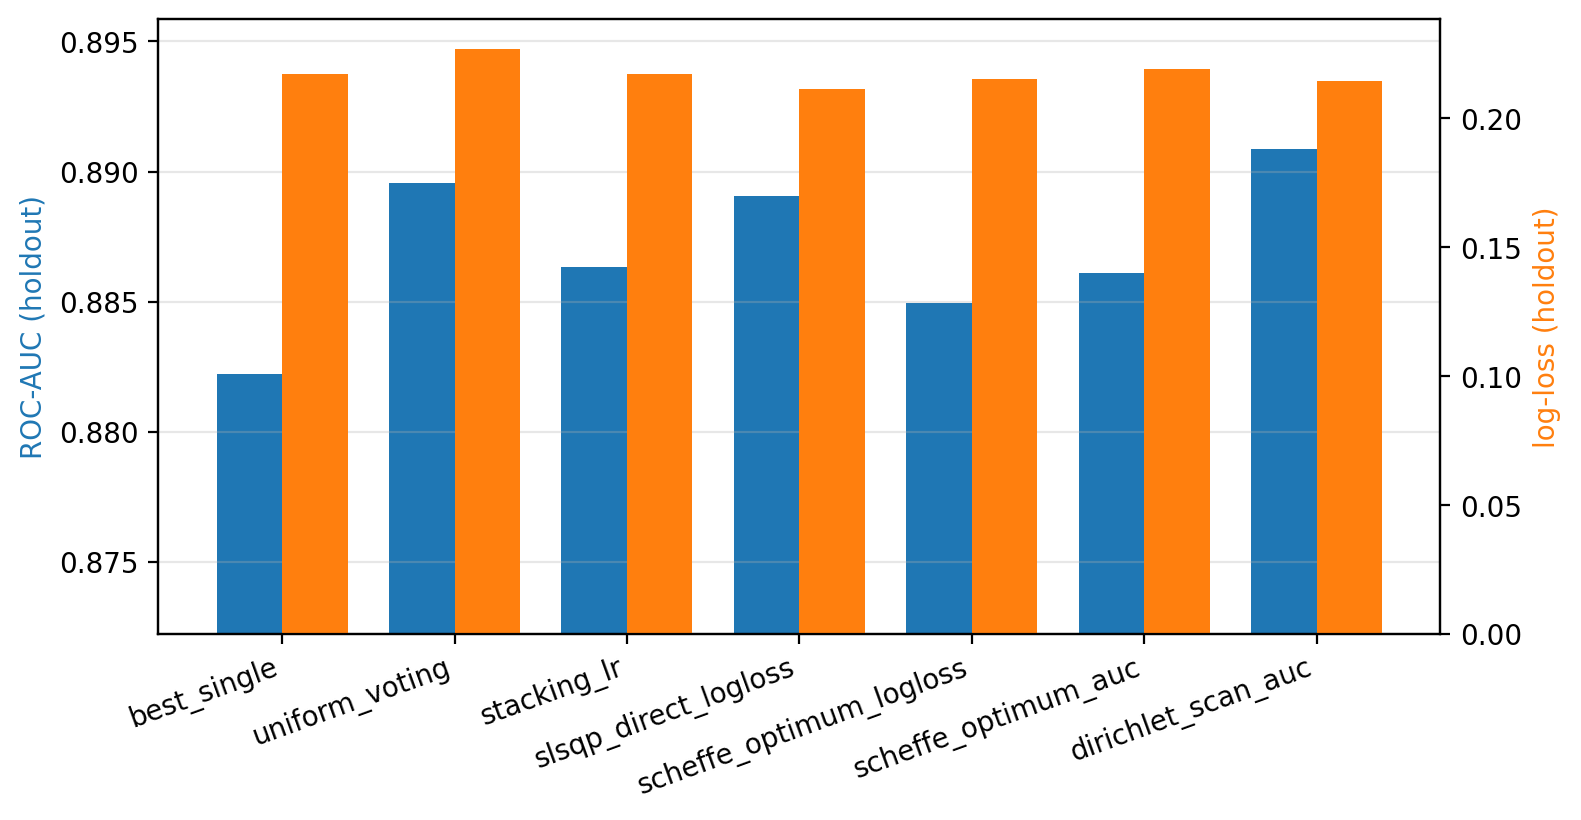

In [12]:
res = pd.read_csv(OUT / 'holdout_results.csv')
display(res[['method', 'roc_auc', 'log_loss', 'brier', 'f1', 'balanced_accuracy',
             'oof_roc_auc', 'oof_log_loss']].round(4))
opt_rep = json.loads((OUT / 'optimization_report.json').read_text())
print('pesos ótimos:', json.dumps(opt_rep['weights'], indent=2))
print('gap Scheffé vs SLSQP direto (log-loss OOF):',
      f"{opt_rep['gap_scheffe_vs_direct_logloss_oof']:.6f}")
from IPython.display import Image
Image(FIG / 'fig6_holdout_comparison.png', width=680)

## 8. Leitura dos resultados

- Os **vértices** do simplex reproduzem os modelos individuais e o **centroide** é o voto uniforme — ambos são pontos do próprio design;
- Os coeficientes lineares do Scheffé estimam a contribuição de cada classificador; os cruzados **β_ij medem complementaridade** (para perdas convexas como o log-loss, a desigualdade de Jensen garante que o blend nunca é pior que a interpolação linear — o sinal de β_ij em log-loss é estruturalmente favorável, e a pergunta científica é a **magnitude relativa** dos pares; em AUC o sinal é livre);
- O ótimo do metamodelo é validado contra o **ótimo global exato do SLSQP** (log-loss é convexa nos pesos) — o metamodelo não é atalho computacional, é o objeto interpretável do estudo;
- A divergência entre `w*` ótimo em **AUC** e em **log-loss** reflete calibração: o GaussianNB é competitivo em ranking, mas superconfiante em probabilidade.